In [10]:
# ==========================================================
# COMMON SETUP
# ==========================================================
#changes to professor's code are noted in comments with **asterisks** in the comment line
#I also tried to put in general notes about the goal of each block to make the written report a little easier when we write it

!pip install scikit-learn seaborn matplotlib requests joblib opencv-python

import os
import zipfile
import random
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# **removed face_recognition since the .npz has embeddings already, no need to create new embeddings**

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("Setup complete.")

Setup complete.


In [11]:
# ==========================================================
# DOWNLOAD GITHUB REPO
# ==========================================================

repo_url = "https://github.com/RachelBaker26/Grp3_ITEC612/archive/refs/heads/main.zip"

print("Downloading repo...")

response = requests.get(repo_url)

with open("repo.zip", "wb") as file:
    file.write(response.content)

print("Unzipping repo...")

with zipfile.ZipFile("repo.zip", "r") as zip_file:
    zip_file.extractall("repo")

repo_folder = "/content/repo/Grp3_ITEC612-main"

print("Repo downloaded.")
print("Files in repo:")

# **changed formatting for readability**
for item in os.listdir(repo_folder):
    print("-", item)

Unzipping repo...
Repo downloaded.
Files in repo:
- Group_Project_Deliverable_2_Face_Detection,_Extraction,_Alignment,_Preprocessing_&_Feature_ExtractionGroup3WIP.ipynb
- Deliverable3_Notebook_Group3.ipynb
- README.md
- Deliv_3_Grp_3.ipynb
- Deliv_3_Grp_3-m.ipynb
- processed_data
- dataset
- face_embeddings.npz
- preprocess_aligned
- ITEC_612_Facial_Recognition_Preprocessing_Group3.ipynb


In [12]:
# ==========================================================
# FIND AND LOAD REQUIRED FILES
# ==========================================================

# **Changed to direct file paths for readability/simplicity**
embedding_file = repo_folder + "/face_embeddings.npz"
preprocess_folder = repo_folder + "/preprocess_aligned"

print("Embedding file exists:", os.path.exists(embedding_file))
print("Preprocess folder exists:", os.path.exists(preprocess_folder))

data = np.load(embedding_file, allow_pickle=True)

print()
print("Items inside face_embeddings.npz:")

for item in data.files:
    print("-", item)

Embedding file exists: True
Preprocess folder exists: True

Items inside face_embeddings.npz:
- train_embeddings
- train_labels
- train_paths
- val_embeddings
- val_labels
- val_paths
- test_embeddings
- test_labels
- test_paths


In [13]:
# ==========================================================
# AUDIT EMBEDDING PATHS
# ==========================================================
# This is an entirely new step b/c I wanted to make sure the .npz pointed to process_aligned images rather than processed_data images

train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

all_paths = list(train_paths) + list(val_paths) + list(test_paths)

preprocess_count = 0
processed_count = 0
other_count = 0

for path in all_paths:
    path_text = str(path)

    if "preprocess_aligned" in path_text:
        preprocess_count += 1
    elif "processed_data" in path_text:
        processed_count += 1
    else:
        other_count += 1

print("Total paths:", len(all_paths))
print("Paths containing preprocess_aligned:", preprocess_count)
print("Paths containing processed_data:", processed_count)
print("Other paths:", other_count)

Total paths: 147
Paths containing preprocess_aligned: 147
Paths containing processed_data: 0
Other paths: 0


In [14]:
# ==========================================================
# LOAD DATA
# ==========================================================

X_train = data["train_embeddings"]
y_train = data["train_labels"]

X_val = data["val_embeddings"]
y_val = data["val_labels"]

X_test = data["test_embeddings"]
y_test = data["test_labels"]

# **added lines for val_paths and train_paths for completeness & consistency **
train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

# added the print below just to make sure the shape of the data is consistent/expected
print("Training data:", X_train.shape, "labels:", len(y_train))
print("Validation data:", X_val.shape, "labels:", len(y_val))
print("Test data:", X_test.shape, "labels:", len(y_test))

Training data: (99, 128) labels: 99
Validation data: (19, 128) labels: 19
Test data: (29, 128) labels: 29


In [15]:
# ==========================================================
# ENCODE LABELS AND SCALE EMBEDDINGS
# ==========================================================

# **Used label_encoder rather than le because I will never remember what le means**
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Added print statement for confirmation
print("Labels encoded and embeddings scaled.")
print()
print("Class names:")

for name in label_encoder.classes_:
    print("-", name)

Labels encoded and embeddings scaled.

Class names:
- A_Daddario
- A_Samberg
- B_Eilish
- B_Pitt
- C_Boseman
- C_Theron
- E_Moss
- H_Jackman
- J_Travolta
- T_Cruise


In [16]:
# -------------------------------
# IMAGE HELPER # refactoring
# -------------------------------
def show_predictions(model, name):
    print(f"\n🔍 {name} - 3 RANDOM TEST PREDICTIONS\n")

    for i in random.sample(range(len(X_test)), 3):

        sample = X_test[i].reshape(1,-1)
        pred = model.predict(sample)[0]
        pred_label = label_encoder.inverse_transform([pred])[0]

        if hasattr(model, "predict_proba"):
            conf = model.predict_proba(sample).max()
        else:
            conf = 1.0

        true_label = y_test[i]
        img_path = test_paths[i]

        if not os.path.exists(img_path):
            fname = os.path.basename(img_path)
            for root, dirs, files in os.walk(preprocess_folder):
                if fname in files:
                    img_path = os.path.join(root,fname)
                    break

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print("True:", true_label, "| Pred:", pred_label, "| Conf:", round(conf,3))

        plt.imshow(img)
        plt.title(f"{name}\nTrue:{true_label} | Pred:{pred_label}")
        plt.axis("off")
        plt.show()

In [17]:
# ==========================================================
# FACE RECOGNITION MODEL 1 - KNN
# ==========================================================

k_values = [1, 3, 5, 7]

# **changed variable names to be more descriptive - easier to reference in code + unlikely to reuse in other models**
# **added best k for specific amd clear definition of the best performing k value**
best_accuracy = 0
best_k = None
best_knn_model = None

# **didn't use test set in this block due to assignment requirements.  Assignment says comparison comes first, then a test step**
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train_encoded)

    val_predictions = knn_model.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val_encoded, val_predictions)

    print("k =", k, "Validation Accuracy:", round(val_accuracy, 4))

# **Added tie logic**
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_k = k
        best_knn_model = knn_model

print()
print("Best k:", best_k)
print("Best KNN Validation Accuracy:", round(best_accuracy, 4))

k = 1 Validation Accuracy: 1.0
k = 3 Validation Accuracy: 1.0
k = 5 Validation Accuracy: 1.0
k = 7 Validation Accuracy: 1.0

Best k: 1
Best KNN Validation Accuracy: 1.0


In [18]:
# ==========================================================
# FACE RECOGNITION MODEL 1 - KNN v2
# ==========================================================
# new code block bc I'm wary of a 100% accuracy across all K values.  Possible due to small dataset, but unusual.

k_values = [1, 3, 5, 7]

results = []
best_accuracy = 0

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train_encoded)

    val_predictions = knn_model.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val_encoded, val_predictions)

    results.append((k, val_accuracy))

    print("k =", k, "Validation Accuracy:", round(val_accuracy, 4))

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy

# Find all k values tied for best validation accuracy
best_k_values = []

for k, accuracy in results:
    if accuracy == best_accuracy:
        best_k_values.append(k)

# Prefer k = 3 if it is tied for best; otherwise use the first best k. Chose k=3 because k=1 is too volatile/weakly supported.
if 3 in best_k_values:
    best_k = 3
else:
    best_k = best_k_values[0]

best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train_encoded)

print()
print("Best k:", best_k)
print("Best KNN Validation Accuracy:", round(best_accuracy, 4))

k = 1 Validation Accuracy: 1.0
k = 3 Validation Accuracy: 1.0
k = 5 Validation Accuracy: 1.0
k = 7 Validation Accuracy: 1.0

Best k: 3
Best KNN Validation Accuracy: 1.0


In [19]:
# ==========================================================
# KNN TEST EVALUATION
# ==========================================================
# Per assignment guidelines - the final KNN model.
# **Changed from professor code to explicitly calculate accuracy, precision, recall, and F1 bc the assignment asks for all four.**

knn_test_predictions = best_knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test_encoded, knn_test_predictions)
knn_precision = precision_score(y_test_encoded, knn_test_predictions, average="weighted", zero_division=0)
knn_recall = recall_score(y_test_encoded, knn_test_predictions, average="weighted", zero_division=0)
knn_f1 = f1_score(y_test_encoded, knn_test_predictions, average="weighted", zero_division=0)

print("KNN Test Results")
print("----------------")
print("Best k:", best_k)
print("Accuracy:", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall:", round(knn_recall, 4))
print("F1-score:", round(knn_f1, 4))

print()
print("KNN Classification Report")
print("-------------------------")

print(classification_report(
    y_test_encoded,
    knn_test_predictions,
    target_names=label_encoder.classes_,
    zero_division=0
))

KNN Test Results
----------------
Best k: 3
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

KNN Classification Report
-------------------------
              precision    recall  f1-score   support

  A_Daddario       1.00      1.00      1.00         3
   A_Samberg       1.00      1.00      1.00         3
    B_Eilish       1.00      1.00      1.00         3
      B_Pitt       1.00      1.00      1.00         2
   C_Boseman       1.00      1.00      1.00         3
    C_Theron       1.00      1.00      1.00         3
      E_Moss       1.00      1.00      1.00         3
   H_Jackman       1.00      1.00      1.00         3
  J_Travolta       1.00      1.00      1.00         3
    T_Cruise       1.00      1.00      1.00         3

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



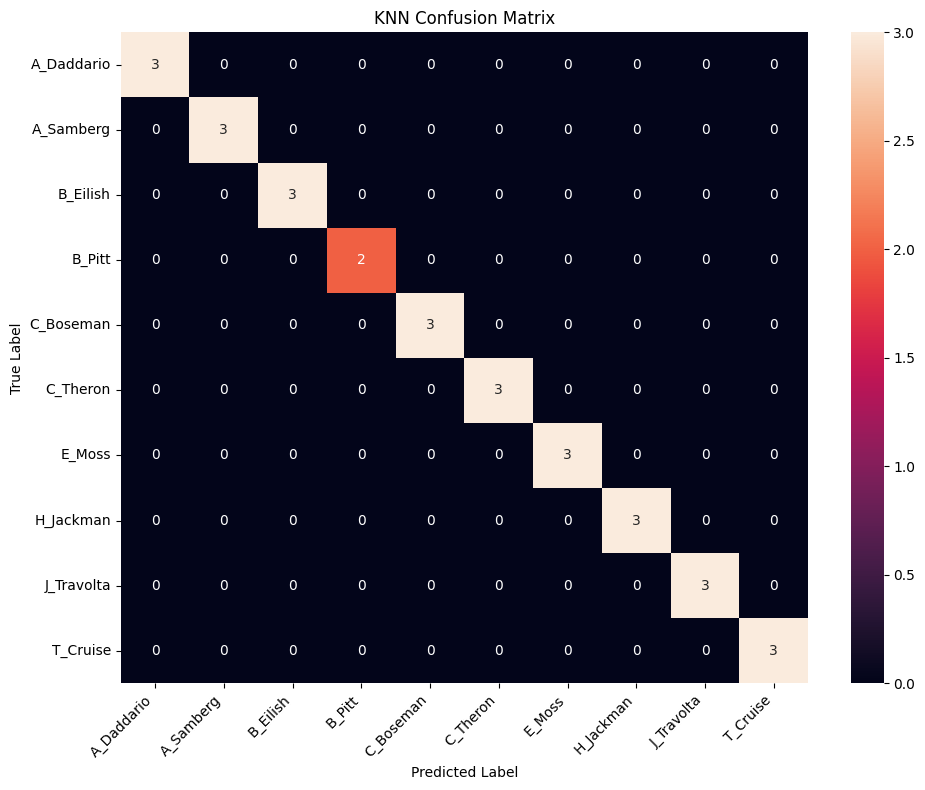

In [20]:
# ==========================================================
# KNN CONFUSION MATRIX
# ==========================================================
#displays where the model was correct/incorrect.
# **Slightly expanded professor code to make labels easier to read.**

knn_matrix = confusion_matrix(y_test_encoded, knn_test_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    knn_matrix,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KNN - 3 Random Test Predictions
-------------------------------
True: A_Samberg
Predicted: A_Samberg
Path: /content/repo/Grp3_ITEC612-main/preprocess_aligned/Facial_Recognition_Test/A_Samberg/Andy Samberg_01.jpg


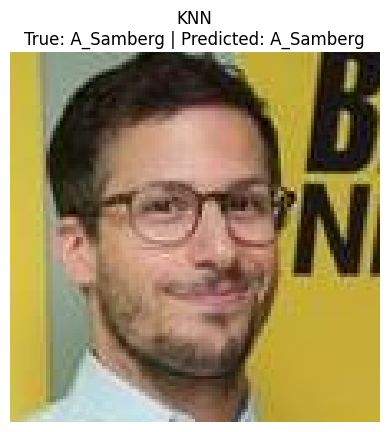


True: A_Daddario
Predicted: A_Daddario
Path: /content/repo/Grp3_ITEC612-main/preprocess_aligned/Facial_Recognition_Test/A_Daddario/Alexandra Daddario_BB.jpg


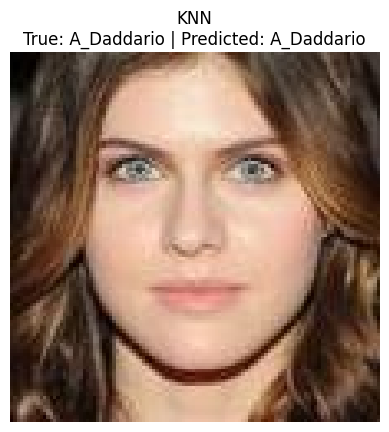


True: J_Travolta
Predicted: J_Travolta
Path: /content/repo/Grp3_ITEC612-main/preprocess_aligned/Facial_Recognition_Test/J_Travolta/John_Travolta_011.jpg


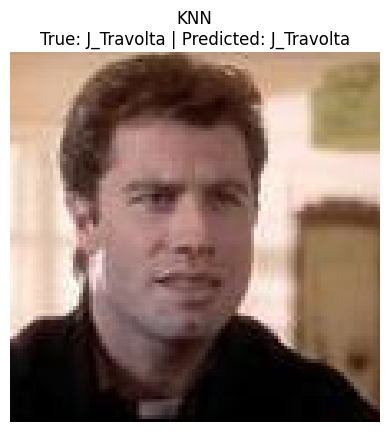

In [21]:
# ==========================================================
# KNN PREDICTION VISUALIZATION
# ==========================================================
# Shows 3 test images w true and predicted labels.
# **Adjusted helper fxn to only look at preprocess_aligned imagess**

def find_image_path(original_path):
    if os.path.exists(original_path):
        return original_path

    file_name = os.path.basename(original_path)

    for root, folders, files in os.walk(preprocess_folder):
        if file_name in files:
            return os.path.join(root, file_name)

    return None


print("KNN - 3 Random Test Predictions")
print("-------------------------------")

sample_indices = random.sample(range(len(X_test_scaled)), 3)

for i in sample_indices:
    true_name = label_encoder.inverse_transform([y_test_encoded[i]])[0]
    predicted_name = label_encoder.inverse_transform([knn_test_predictions[i]])[0]

    image_path = find_image_path(test_paths[i])

    print("True:", true_name)
    print("Predicted:", predicted_name)
    print("Path:", image_path)

    if image_path is not None:
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.imshow(image)
        plt.title(f"KNN\nTrue: {true_name} | Predicted: {predicted_name}")
        plt.axis("off")
        plt.show()
    else:
        print("Image not found.")

    print()

In [22]:
#SUPPORT VECTOR MACHINE (SVM) Training
from sklearn.svm import SVC

best_acc = 0
best_model = None
for kernel in ['linear','rbf']:
    for C in [0.1,1,10]:

        model = SVC(kernel=kernel, C=C, probability=True)
        model.fit(X_train, y_train_encoded)

        val_pred = model.predict(X_val)
        acc = accuracy_score(y_val_encoded, val_pred)

        print(kernel, C, "Val Acc:", acc)
        if acc > best_acc:
            best_acc = acc
            best_model = model
print("\nBest SVM Val Accuracy:", best_acc)

linear 0.1 Val Acc: 0.10526315789473684
linear 1 Val Acc: 1.0
linear 10 Val Acc: 1.0
rbf 0.1 Val Acc: 0.10526315789473684
rbf 1 Val Acc: 1.0
rbf 10 Val Acc: 1.0

Best SVM Val Accuracy: 1.0



SVM TEST RESULTS
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



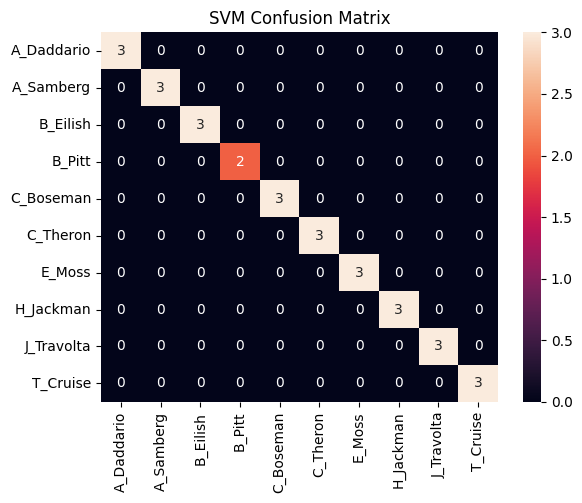


🔍 SVM - 3 RANDOM TEST PREDICTIONS

True: B_Eilish | Pred: B_Eilish | Conf: 0.674


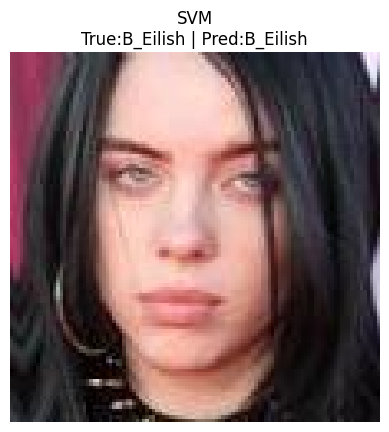

True: J_Travolta | Pred: J_Travolta | Conf: 0.621


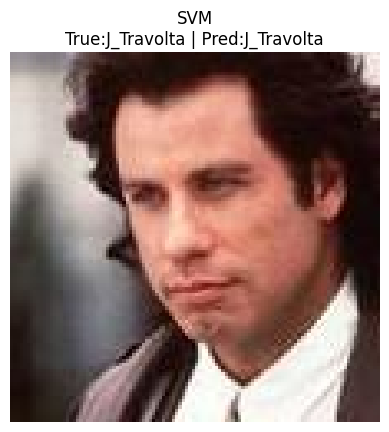

True: E_Moss | Pred: E_Moss | Conf: 0.592


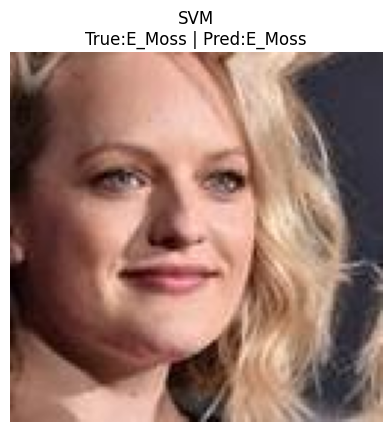

In [23]:
# testing and visualizing SVM
svm_pred = best_model.predict(X_test)

print("\nSVM TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_encoded,svm_pred))
print(classification_report(y_test_encoded,svm_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_encoded,svm_pred), annot=True,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("SVM Confusion Matrix")
plt.show()

show_predictions(best_model, "SVM")
#having monkeyed around some, I'm convinced that this is actually working correctly. I'm just suprised it is nearly 100% acc very spooky.

In [27]:
# FACE RECOGNITION MODEL 4 - COSINE SIMILARITY
from sklearn.metrics.pairwise import cosine_similarity

def predict_cosine(test_emb):
    sims = cosine_similarity([test_emb], X_train)[0]
    idx = np.argmax(sims)
    return y_train[idx], sims[idx]

# VALIDATION
val_preds = []
for emb in X_val:
    label,_ = predict_cosine(emb)
    val_preds.append(label)

print("Cosine Val Accuracy:", accuracy_score(y_val_encoded, label_encoder.transform(val_preds)))




Cosine Val Accuracy: 1.0


Cosine Val Accuracy: 1.0

COSINE TEST RESULTS
Accuracy: 1.0
              precision    recall  f1-score   support

  A_Daddario       1.00      1.00      1.00         3
   A_Samberg       1.00      1.00      1.00         3
    B_Eilish       1.00      1.00      1.00         3
      B_Pitt       1.00      1.00      1.00         2
   C_Boseman       1.00      1.00      1.00         3
    C_Theron       1.00      1.00      1.00         3
      E_Moss       1.00      1.00      1.00         3
   H_Jackman       1.00      1.00      1.00         3
  J_Travolta       1.00      1.00      1.00         3
    T_Cruise       1.00      1.00      1.00         3

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



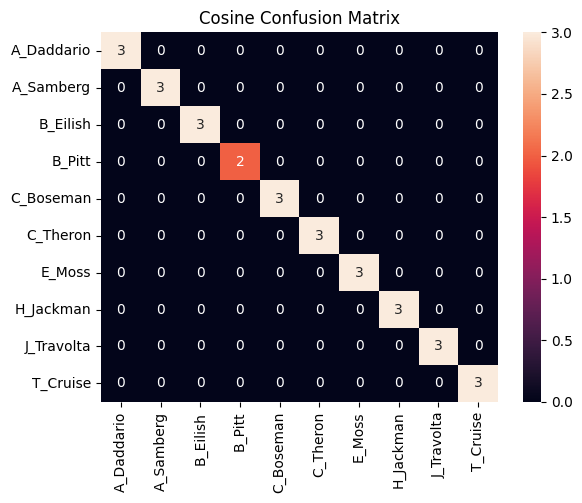


🔍 Cosine - 3 RANDOM TEST PREDICTIONS

True: A_Samberg | Pred: A_Samberg | Sim: 0.965


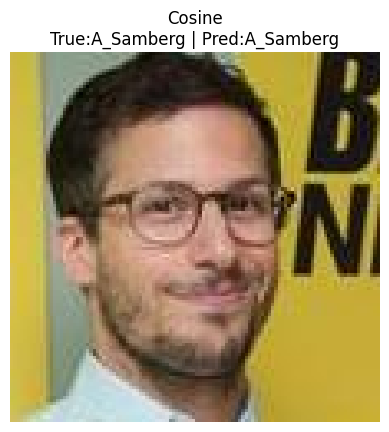

True: A_Daddario | Pred: A_Daddario | Sim: 0.979


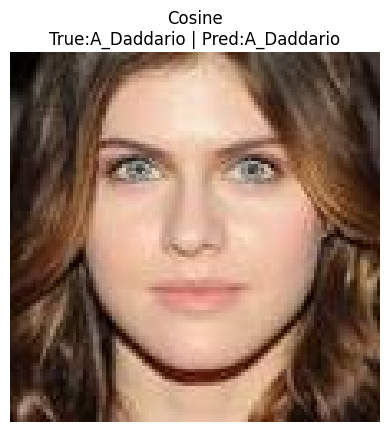

True: A_Samberg | Pred: A_Samberg | Sim: 0.97


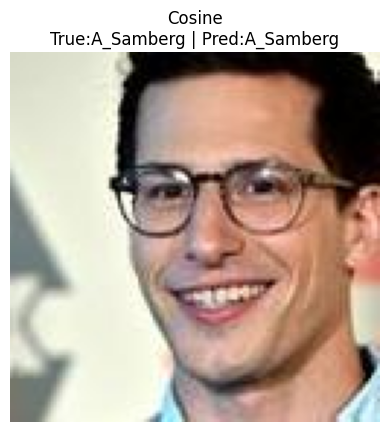

In [ ]:
# TEST COSINE SIMILARITY
test_preds = []
for emb in X_test:
    label,_ = predict_cosine(emb)
    test_preds.append(label)

print("\nCOSINE TEST RESULTS")
print("Accuracy:", accuracy_score(y_test,test_preds))
print(classification_report(y_test,test_preds))

sns.heatmap(confusion_matrix(y_test,test_preds,labels=label_encoder.classes_),
            annot=True, xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Cosine Confusion Matrix")
plt.show()

# VISUALIZE 3
print("\n🔍 Cosine - 3 RANDOM TEST PREDICTIONS\n")

for i in random.sample(range(len(X_test)), 3):

    pred_label, conf = predict_cosine(X_test[i])
    true_label = y_test[i]

    img_path = test_paths[i]

    if not os.path.exists(img_path):
        fname = os.path.basename(img_path)
        for root, dirs, files in os.walk(preprocess_folder):
            if fname in files:
                img_path = os.path.join(root,fname)
                break

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("True:", true_label, "| Pred:", pred_label, "| Sim:", round(float(conf),3))

    plt.imshow(img)
    plt.title(f"Cosine\nTrue:{true_label} | Pred:{pred_label}")
    plt.axis("off")
    plt.show()